In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import StratifiedKFold

from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist
from pymoo.indicators.hv import HV

from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

### LOAD and PRE-PROCESS the DATA

In [2]:
#  Load + Clean Data

df = pd.read_csv("adult.csv")
df.columns = df.columns.str.strip()

df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

df["income"] = df["income"].astype(str).str.strip().str.replace(".", "", regex=False)
df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

# Sensitive attribute
df["sex"] = df["sex"].str.strip()
sensitive_feature = df["sex"].apply(lambda x: 1 if x == "Male" else 0)

print("Dataset shape:", df.shape)

Dataset shape: (30162, 15)


In [3]:
#  Basic Distribution Checks

print("\n=== TARGET DISTRIBUTION ===")
print(df["income"].value_counts(normalize=True))

print("\n=== SENSITIVE ATTRIBUTE DISTRIBUTION ===")
print(sensitive_feature.value_counts(normalize=True))

print("\n=== GROUP vs TARGET ===")
print(pd.crosstab(sensitive_feature, df["income"], normalize='index'))


=== TARGET DISTRIBUTION ===
income
0    0.751078
1    0.248922
Name: proportion, dtype: float64

=== SENSITIVE ATTRIBUTE DISTRIBUTION ===
sex
1    0.675685
0    0.324315
Name: proportion, dtype: float64

=== GROUP vs TARGET ===
income         0         1
sex                       
0       0.886322  0.113678
1       0.686163  0.313837


In [4]:
#  Feature Engineering

X = df.drop(columns=["income", "sex"])
y = df["income"]

categorical_cols = X.select_dtypes(include=["object", "string"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X_encoded, y, sensitive_feature,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nTrain shape:", X_train_scaled.shape)


Train shape: (24129, 95)


### INITIAL DATA EXPLORATION and SELECTION OF OBJECTIVES
##### Checking sensitive varibles v/s final label distribution
##### We also check various objectives


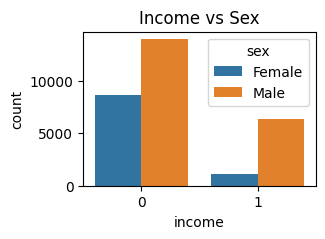

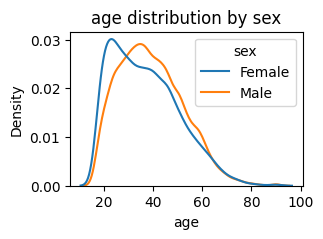

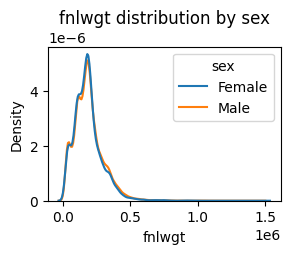

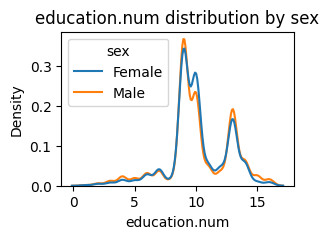

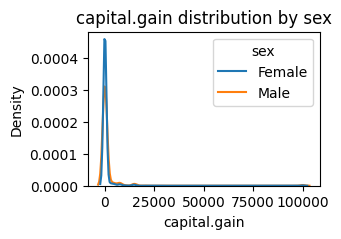

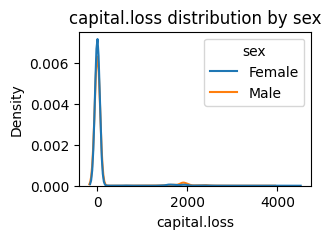

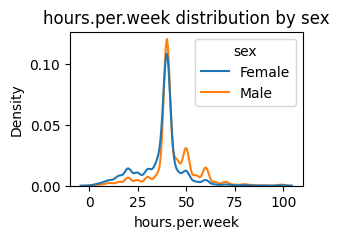

In [5]:
# Visual Data Inspection
# Income vs Sex

plt.figure(figsize=(3, 2))
sns.countplot(x=df["income"], hue=df["sex"])
plt.title("Income vs Sex")
plt.show()

for col in numeric_cols:
    plt.figure(figsize=(3, 2))  
    sns.kdeplot(data=df, x=col, hue="sex", common_norm=False)
    plt.title(f"{col} distribution by sex")
    plt.show()

In [6]:
#  Proxy Feature Detection 

print("\n=== PROXY FEATURE CORRELATION WITH SEX ===")

corrs = {}

for col in X_encoded.columns:
    corrs[col] = np.corrcoef(X_encoded[col], sensitive_feature)[0,1]

corr_series = pd.Series(corrs).abs().sort_values(ascending=False)

print(corr_series.head(20))


=== PROXY FEATURE CORRELATION WITH SEX ===
marital.status_Married-civ-spouse    0.437485
relationship_Unmarried               0.326334
relationship_Wife                    0.318830
hours.per.week                       0.231268
occupation_Craft-repair              0.227105
marital.status_Widowed               0.181200
marital.status_Never-married         0.175420
relationship_Not-in-family           0.172044
occupation_Other-service             0.164464
occupation_Transport-moving          0.133776
race_Black                           0.118145
marital.status_Separated             0.109889
workclass_Self-emp-not-inc           0.107515
race_White                           0.105148
relationship_Own-child               0.102220
occupation_Farming-fishing           0.101711
occupation_Handlers-cleaners         0.093792
occupation_Priv-house-serv           0.091374
workclass_Self-emp-inc               0.084968
age                                  0.081993
dtype: float64


In [7]:
#  Baseline Model 

model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

f1 = f1_score(y_test, y_pred)

print("\n=== BASELINE PERFORMANCE ===")
print("F1:", f1)


=== BASELINE PERFORMANCE ===
F1: 0.6795761782974059


In [8]:
#  Baseline Fairness

dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=s_test)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=s_test)

dp = 1 - abs(dp_diff)
eo = 1 - abs(eo_diff)

print("\n=== BASELINE FAIRNESS ===")
print("DP (fairness score):", dp)
print("EO (fairness score):", eo)


=== BASELINE FAIRNESS ===
DP (fairness score): 0.8293877080813317
EO (fairness score): 0.9288710585585586


In [9]:
# Group-wise Performance 

print("\n=== GROUP-WISE METRICS ===")

for group in [0, 1]:
    idx = (s_test == group)
    print(f"\nGroup {group}:")
    print("F1:", f1_score(y_test[idx], y_pred[idx]))
    print("Recall:", recall_score(y_test[idx], y_pred[idx]))
    print("Samples:", np.sum(idx))


=== GROUP-WISE METRICS ===

Group 0:
F1: 0.6310432569974554
Recall: 0.5585585585585585
Samples: 1929

Group 1:
F1: 0.6877133105802048
Recall: 0.6296875
Samples: 4104


In [11]:
# Define a simple individual fairness metric

def individual_fairness_score(X, y_pred, sample_size=1000):
    np.random.seed(42)

    idx = np.random.choice(len(X), size=min(sample_size, len(X)), replace=False)
    
    X_sample = X.iloc[idx].values
    y_sample = y_pred[idx]

    dists = euclidean_distances(X_sample)

    # remove self-comparisons
    np.fill_diagonal(dists, np.inf)

    # stricter similarity
    threshold = np.percentile(dists, 5)
    similar = dists < threshold

    pred_diff = np.abs(y_sample[:, None] - y_sample[None, :])

    score = 1 - np.mean(pred_diff[similar])

    return score

distance_cols = ["age", "education.num", "hours.per.week"]

X_dist = X_test_scaled[distance_cols]

if_score = individual_fairness_score(X_dist, y_pred)

print("\n=== BASELINE INDIVIDUAL FAIRNESS ===")
print("IF score:", if_score)


=== BASELINE INDIVIDUAL FAIRNESS ===
IF score: 0.8313771203472948


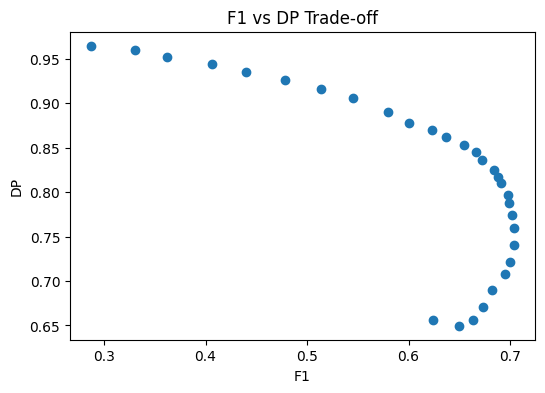

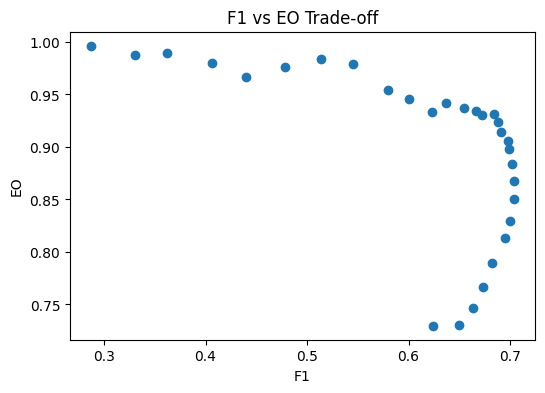

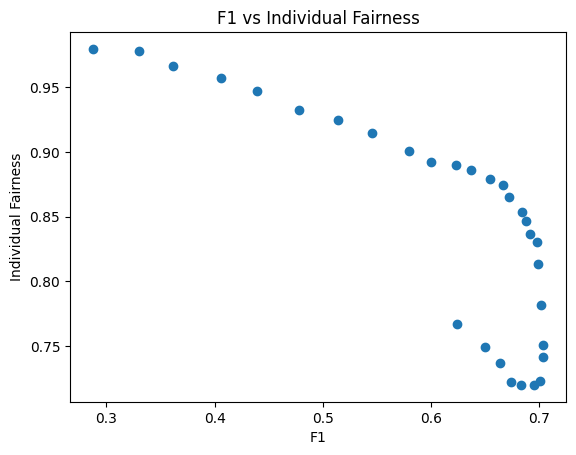

In [12]:
#  Threshold Trade-off Analysis 

probs = model.predict_proba(X_test_scaled)[:,1]

thresholds = np.linspace(0.1, 0.9, 30)

results = []

for t in thresholds:
    y_pred_t = (probs >= t).astype(int)

    f1 = f1_score(y_test, y_pred_t)
    dp = 1 - abs(demographic_parity_difference(y_test, y_pred_t, sensitive_features=s_test))
    eo = 1 - abs(equalized_odds_difference(y_test, y_pred_t, sensitive_features=s_test))
    if_score = individual_fairness_score(X_test_scaled, y_pred_t)

    results.append((f1, dp, eo, if_score))

results = np.array(results)

plt.figure(figsize=(6, 4))
plt.scatter(results[:,0], results[:,1])
plt.xlabel("F1")
plt.ylabel("DP")
plt.title("F1 vs DP Trade-off")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(results[:,0], results[:,2])
plt.xlabel("F1")
plt.ylabel("EO")
plt.title("F1 vs EO Trade-off")
plt.show()

plt.figure()
plt.scatter(results[:,0], results[:,3])
plt.xlabel("F1")
plt.ylabel("Individual Fairness")
plt.title("F1 vs Individual Fairness")
plt.show()

In [13]:
# Objective Correlation Check

print("\n=== OBJECTIVE CORRELATION ===")
print(np.corrcoef(results.T))


=== OBJECTIVE CORRELATION (WITH IF) ===
[[ 1.         -0.74957524 -0.59356783 -0.79980674]
 [-0.74957524  1.          0.97255932  0.96689566]
 [-0.59356783  0.97255932  1.          0.90541689]
 [-0.79980674  0.96689566  0.90541689  1.        ]]


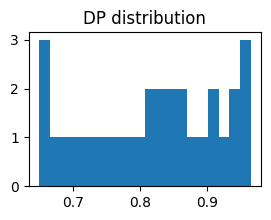

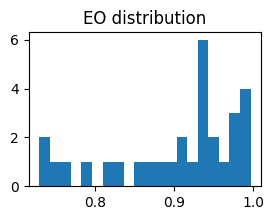

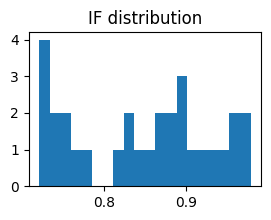

In [14]:
#  Metric Spread 

plt.figure(figsize=(3, 2))
plt.hist(results[:,1], bins=20)
plt.title("DP distribution")
plt.show()

plt.figure(figsize=(3, 2))
plt.hist(results[:,2], bins=20)
plt.title("EO distribution")
plt.show()

plt.figure(figsize=(3, 2))
plt.hist(results[:,3], bins=20)
plt.title("IF distribution")
plt.show()

### DEFINING MODELS, OBJECTIVE FUNCTIONS and related METRICS

In [15]:
def train_model(model_type, reg, n_trees, depth, min_samples_leaf, class_weight_scale, X_tr, y_tr):

    if class_weight_scale > 1:
        class_weight = {0: 1.0, 1: class_weight_scale}
    else:
        class_weight = None

    if model_type == 0:
        model = LogisticRegression(
            C=1/reg,
            max_iter=300,
            class_weight=class_weight,
            solver="liblinear",
            random_state=42
        )
    else:
        model = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            min_samples_leaf=min_samples_leaf,
            class_weight=class_weight,
            n_jobs=-1,
            random_state=42
        )

    model.fit(X_tr, y_tr)
    return model

In [16]:
# Group Threshold Predictions 

def predict_group_threshold(model, X, sensitive, t_male, t_female):

    probs = model.predict_proba(X)[:, 1]

    thresholds = np.where(sensitive == 1, t_male, t_female)
    preds = (probs >= thresholds).astype(int)

    return preds

In [17]:
# Metrics

from sklearn.metrics import f1_score
from fairlearn.metrics import demographic_parity_difference

def evaluate_metrics(y_true, y_pred, sensitive):

    f1 = f1_score(y_true, y_pred)

    dp = 1 - abs(
        demographic_parity_difference(
            y_true, y_pred, sensitive_features=sensitive
        )
    )

    return f1, dp

In [18]:
# Complexity Metric 

def model_complexity(model, model_type):

    ####### i was using this previously (let's call it "raw complexity" for now)
    # if model_type == 0:
    #     # Logistic Regression → number of coefficients
    #     return np.sum(np.abs(model.coef_))
    # else:
    #     # Random Forest → total number of nodes
    #     return sum(tree.tree_.node_count for tree in model.estimators_)
    
    if model_type == 0:
        return np.sum(np.abs(model.coef_))
    else:
        return np.log(sum(tree.tree_.node_count for tree in model.estimators_) + 1)

In [19]:
#  CROSS-VALIDATED Evaluation

def evaluate_solution(x):

    model_type = int(round(x[0]))
    reg = x[1]
    n_trees = int(x[2])
    depth = int(x[3])
    min_samples_leaf = int(x[4])
    class_weight_scale = x[5]
    t_male = x[6]
    t_female = x[7]

    # Clip thresholds
    t_male = np.clip(t_male, 0.3, 0.7)
    t_female = np.clip(t_female, 0.3, 0.7)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    f1s, dps, comps = [], [], []

    for train_idx, val_idx in skf.split(X_train_scaled, y_train):

        X_tr = X_train_scaled.iloc[train_idx]
        X_val = X_train_scaled.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        s_tr = s_train.iloc[train_idx]
        s_val = s_train.iloc[val_idx]

        model = train_model(
            model_type, reg, n_trees, depth,
            min_samples_leaf, class_weight_scale,
            X_tr, y_tr
        )

        y_pred = predict_group_threshold(model, X_val, s_val, t_male, t_female)

        # reject degenerate predictions
        pos_rate = np.mean(y_pred)
        if pos_rate < 0.05 or pos_rate > 0.95:
            continue

        f1, dp = evaluate_metrics(y_val, y_pred, s_val)
        comp = model_complexity(model, model_type)

        f1s.append(f1)
        dps.append(dp)
        comps.append(comp)

    if len(f1s) == 0:
        return 0.0, 0.0, 1e6

    return np.mean(f1s), np.mean(dps), np.mean(comps)

### DEFINING POO MODEL CLASS

In [20]:
# Define PyMOO Problem 

from pymoo.core.problem import Problem

class FairnessMOO(Problem):

    def __init__(self):
        super().__init__(
            n_var=8,
            n_obj=3,
            xl=np.array([0, 1e-4, 100, 5, 1, 0.5, 0.3, 0.3]),
            xu=np.array([1, 10, 500, 25, 10, 3.0, 0.7, 0.7])
        )

    def _evaluate(self, X, out, *args, **kwargs):

        results = []

        for x in X:
            f1, dp, comp = evaluate_solution(x)

            # minimize all
            results.append([
                -f1,        # maximize F1
                -dp,        # maximize fairness
                comp        # minimize complexity
            ])

        out["F"] = np.array(results)

### RUNNING THE NSGA-II ALGORITHM

In [22]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize


algorithm = NSGA2(pop_size=100)

res = minimize(
    FairnessMOO(),
    algorithm,
    ('n_gen', 80),
    seed=42,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     32 |             - |             -
     2 |      200 |     37 |  0.0226061479 |         ideal
     3 |      300 |     55 |  0.0237169803 |         ideal
     4 |      400 |     72 |  0.6657448268 |         nadir
     5 |      500 |     77 |  0.0044795269 |         ideal
     6 |      600 |     80 |  0.0137304954 |         ideal
     7 |      700 |    100 |  0.0093270110 |         ideal
     8 |      800 |    100 |  0.0027458282 |         ideal
     9 |      900 |    100 |  0.0039366119 |         ideal
    10 |     1000 |    100 |  0.0047489210 |         ideal
    11 |     1100 |    100 |  0.0090944216 |             f
    12 |     1200 |    100 |  0.0105380266 |             f
    13 |     1300 |    100 |  0.0072427826 |         ideal
    14 |     1400 |    100 |  0.0449575033 |         nadir
    15 |     1500 |    100 |  0.0086903149 |             f
    16 |     1600 |    100 |  0.0163285553 |            

In [23]:
F = res.F.copy()
F[:,0] *= -1  # F1
F[:,1] *= -1  # DP

X_res = res.X

f1, dp, comp = F[:,0], F[:,1], F[:,2]

In [25]:
print("Distribution of solutions:")

print("f1 min:", f1.min(), "f1 max:", f1.max())
print("dp min:", dp.min(), "dp max:", dp.max())
print("comp min:", comp.min(), "comp max:", comp.max())

Distribution of solutions:
f1 min: 0.30884184308841844 f1 max: 0.7133590991872403
dp min: 0.6856067930507085 dp max: 0.9992653118406448
comp min: 8.352704859302817 comp max: 14.351523524119502


### PLOTTING THE RESULTS

##### Plotting the trade off curves for all populations points from last generation

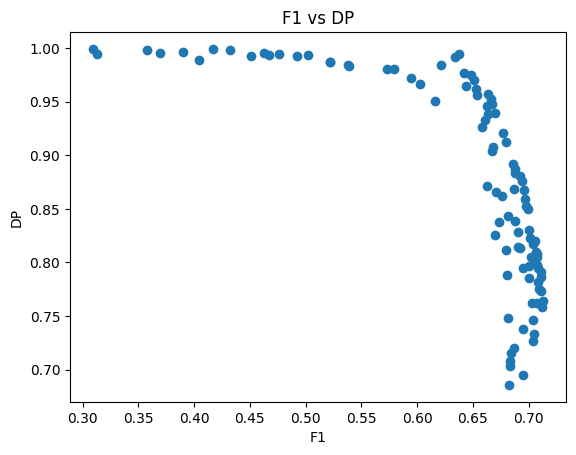

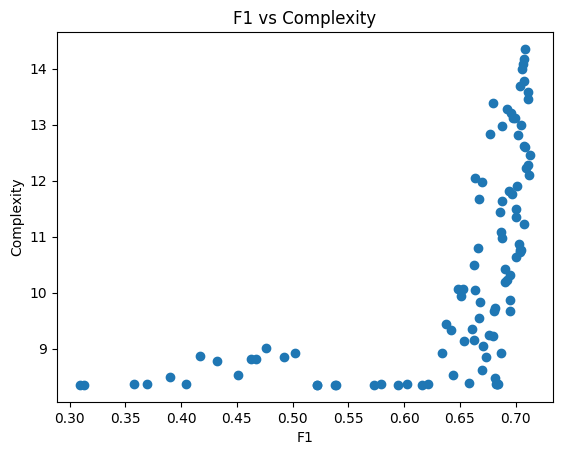

In [26]:
plt.scatter(f1, dp)
plt.xlabel("F1")
plt.ylabel("DP")
plt.title("F1 vs DP")
plt.show()

plt.scatter(f1, comp)
plt.xlabel("F1")
plt.ylabel("Complexity")
plt.title("F1 vs Complexity")
plt.show()

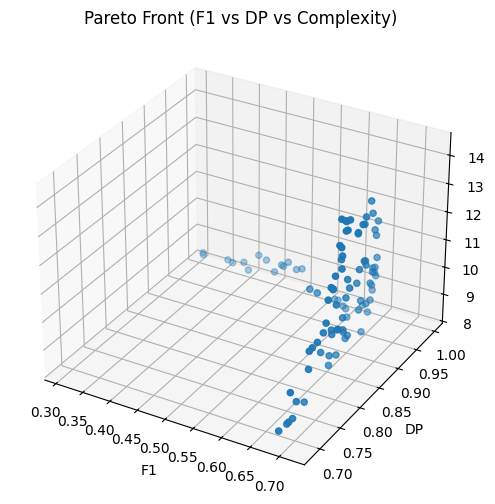

In [27]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(f1, dp, comp)

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

ax.set_title("Pareto Front (F1 vs DP vs Complexity)")

plt.show()

In [28]:
# normalize objectives
f1_n = (f1 - f1.min()) / (f1.max() - f1.min())
dp_n = (dp - dp.min()) / (dp.max() - dp.min())
comp_n = (comp - comp.min()) / (comp.max() - comp.min())

# ideal = (max f1, max dp, min comp)
ideal = np.array([1, 1, 0])

points = np.vstack([f1_n, dp_n, comp_n]).T

# distance to ideal
dist = np.linalg.norm(points - ideal, axis=1)

best_idx = np.argmin(dist)

print("Best solution index:", best_idx)
print("F1:", f1[best_idx])
print("DP:", dp[best_idx])
print("Complexity:", comp[best_idx])

Best solution index: 81
F1: 0.6439503370913635
DP: 0.9644303799977973
Complexity: 8.522652529013628


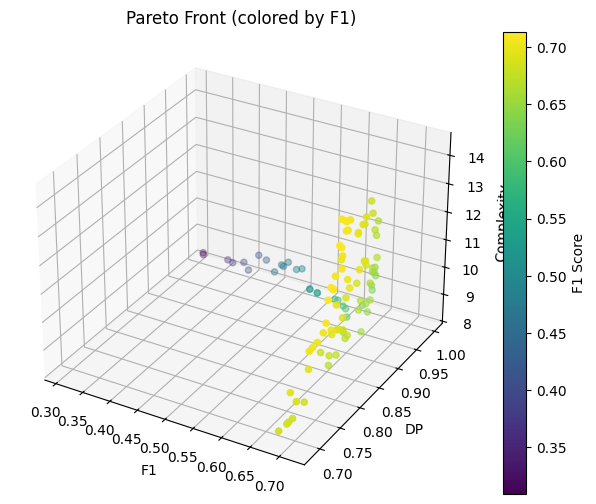

In [29]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(f1, dp, comp, c=f1, cmap='viridis')

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

plt.colorbar(sc, label="F1 Score")

plt.title("Pareto Front (colored by F1)")

plt.show()

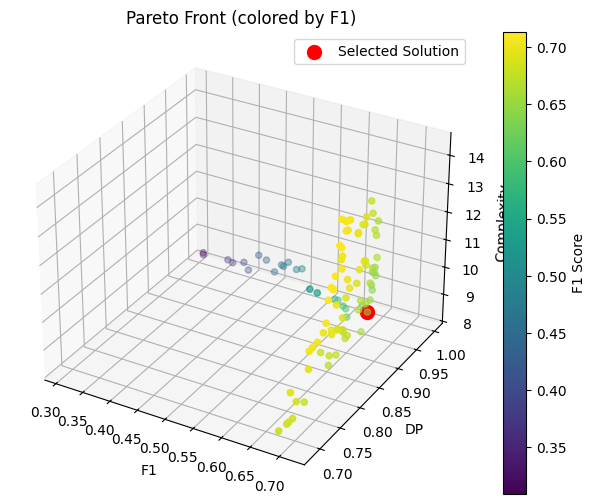

In [30]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    f1[best_idx],
    dp[best_idx],
    comp[best_idx],
    color='red',
    s=100,
    label='Selected Solution'
)

ax.legend()
sc = ax.scatter(f1, dp, comp, c=f1, cmap='viridis')

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

plt.colorbar(sc, label="F1 Score")

plt.title("Pareto Front (colored by F1)")

plt.show()

#### SELECTING CANDIDATE POINTS

In [31]:
# Normalize objectives (required)import numpy as np

f1_n = (f1 - f1.min()) / (f1.max() - f1.min())
dp_n = (dp - dp.min()) / (dp.max() - dp.min())
comp_n = (comp - comp.min()) / (comp.max() - comp.min())

In [32]:
# Compute knee score (distance to ideal)
# Ideal point = max F1, max DP, min complexity → (1, 1, 0)

points = np.vstack([f1_n, dp_n, comp_n]).T
ideal = np.array([1, 1, 0])

dist = np.linalg.norm(points - ideal, axis=1)

In [33]:
# Get top 3 candidates

top3_idx = np.argsort(dist)[:3]

print("Top 3 candidate indices:", top3_idx)

for i, idx in enumerate(top3_idx):
    print(f"\nCandidate {i+1}")
    print("F1:", f1[idx])
    print("DP:", dp[idx])
    print("Complexity:", comp[idx])

Top 3 candidate indices: [81 90 98]

Candidate 1
F1: 0.6439503370913635
DP: 0.9644303799977973
Complexity: 8.522652529013628

Candidate 2
F1: 0.6336241948877025
DP: 0.9918848359171676
Complexity: 8.914646663155771

Candidate 3
F1: 0.6214262777740704
DP: 0.9846558952599199
Complexity: 8.366417389936577


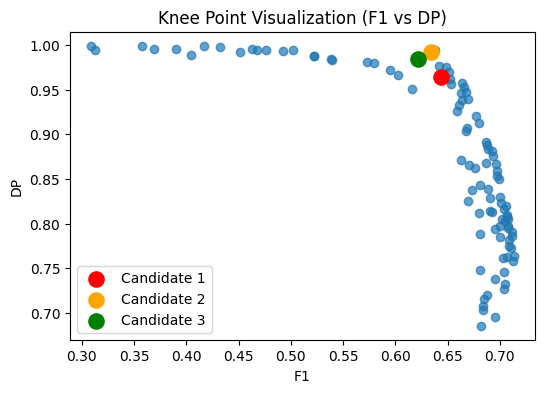

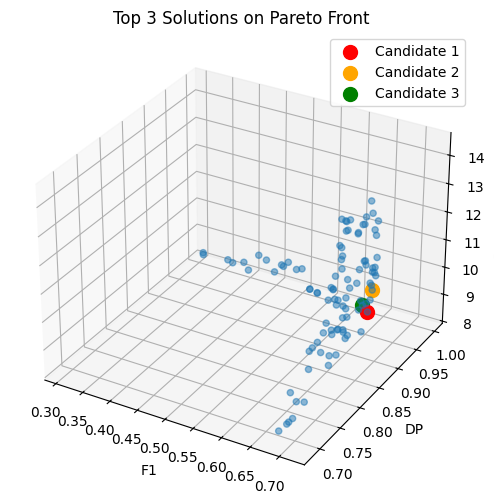

In [34]:
# Visualize knee point (2D)

plt.figure(figsize=(6,4))
plt.scatter(f1, dp, alpha=0.7)

colors = ['red', 'orange', 'green']
for i, idx in enumerate(top3_idx):
    plt.scatter(f1[idx], dp[idx], color=colors[i], s=120, label=f"Candidate {i+1}")

plt.xlabel("F1")
plt.ylabel("DP")
plt.title("Knee Point Visualization (F1 vs DP)")
plt.legend()
plt.show()




fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(f1, dp, comp, alpha=0.5)

for i, idx in enumerate(top3_idx):
    ax.scatter(
        f1[idx],
        dp[idx],
        comp[idx],
        color=colors[i],
        s=100,
        label=f"Candidate {i+1}"
    )

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")
ax.set_title("Top 3 Solutions on Pareto Front")

ax.legend()
plt.show()

In [35]:
nds = NonDominatedSorting().do(F, only_non_dominated_front=True)

print(len(nds), len(F))

19 100


In [ ]:

from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
import numpy as np

### PLOTTING THE PARETO PLOTS

In [36]:
# Extract TRUE Pareto Front

# Get indices of non-dominated points
nds = NonDominatedSorting().do(F, only_non_dominated_front=True)

# Extract Pareto front
F_pareto = F[nds]
X_pareto = X_res[nds]

f1_p = F_pareto[:, 0]
dp_p = F_pareto[:, 1]
comp_p = F_pareto[:, 2]

print("Pareto points:", len(f1_p))

Pareto points: 19


In [37]:
print("Original f1 range:", f1.min(), f1.max())
print("Pareto f1 range:", f1_p.min(), f1_p.max())

Original f1 range: 0.30884184308841844 0.7133590991872403
Pareto f1 range: 0.30884184308841844 0.6823290404389674


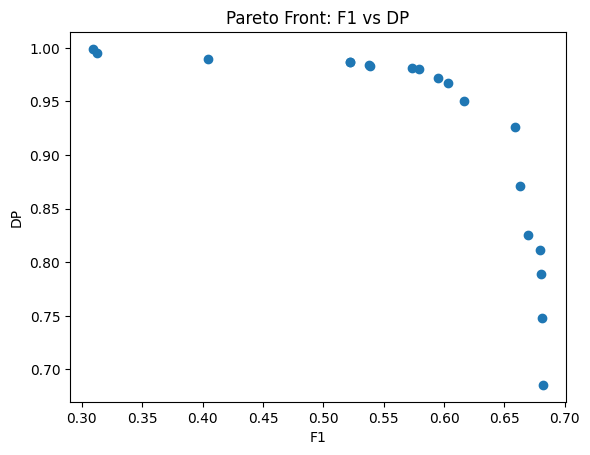

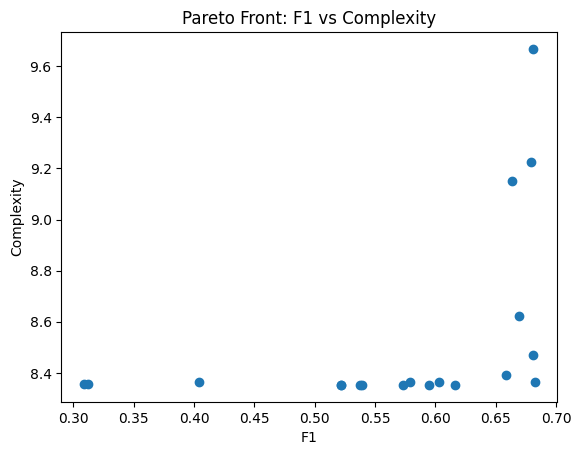

In [38]:
# Plot Trade-offs 

plt.scatter(f1_p, dp_p)
plt.xlabel("F1")
plt.ylabel("DP")
plt.title("Pareto Front: F1 vs DP")
plt.show()

plt.scatter(f1_p, comp_p)
plt.xlabel("F1")
plt.ylabel("Complexity")
plt.title("Pareto Front: F1 vs Complexity")
plt.show()

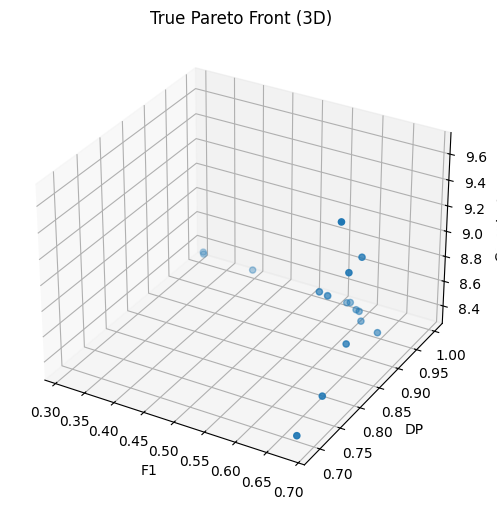

In [39]:
#  3D Pareto Plot

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(f1_p, dp_p, comp_p)

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

ax.set_title("True Pareto Front (3D)")

plt.show()

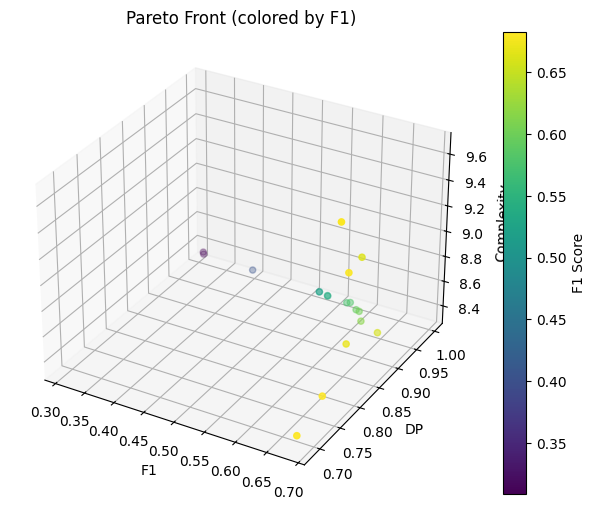

In [40]:
# 3D Plot (colored by F1)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(f1_p, dp_p, comp_p, c=f1_p, cmap='viridis')

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

plt.colorbar(sc, label="F1 Score")
plt.title("Pareto Front (colored by F1)")

plt.show()

In [41]:
# Normalize 

f1_n = (f1_p - f1_p.min()) / (f1_p.max() - f1_p.min())
dp_n = (dp_p - dp_p.min()) / (dp_p.max() - dp_p.min())
comp_n = (comp_p - comp_p.min()) / (comp_p.max() - comp_p.min())

In [42]:
# Knee Point 

points = np.vstack([f1_n, dp_n, comp_n]).T
ideal = np.array([1, 1, 0])

dist = np.linalg.norm(points - ideal, axis=1)

best_idx = np.argmin(dist)

print("Best solution index:", best_idx)
print("F1:", f1_p[best_idx])
print("DP:", dp_p[best_idx])
print("Complexity:", comp_p[best_idx])

Best solution index: 8
F1: 0.6161430077367434
DP: 0.9504424628876138
Complexity: 8.352704859302817


In [43]:
# Top 3 Candidates 

top3_idx = np.argsort(dist)[:3]

print("Top 3 candidate indices:", top3_idx)

for i, idx in enumerate(top3_idx):
    print(f"\nCandidate {i+1}")
    print("F1:", f1_p[idx])
    print("DP:", dp_p[idx])
    print("Complexity:", comp_p[idx])

Top 3 candidate indices: [ 8  7 10]

Candidate 1
F1: 0.6161430077367434
DP: 0.9504424628876138
Complexity: 8.352704859302817

Candidate 2
F1: 0.6028525977354656
DP: 0.9667564835231691
Complexity: 8.365627781524097

Candidate 3
F1: 0.6585454816619206
DP: 0.926049624872538
Complexity: 8.392943365032993


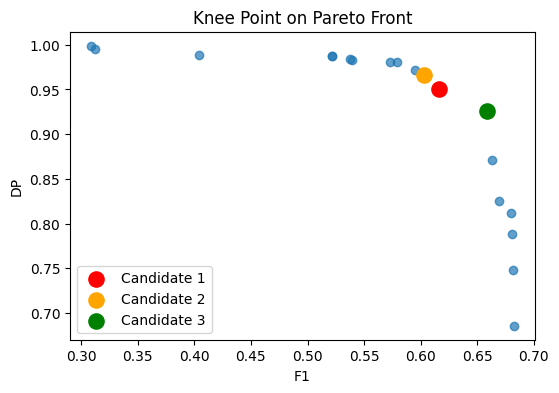

In [44]:
# 2D Knee Visualization

plt.figure(figsize=(6,4))
plt.scatter(f1_p, dp_p, alpha=0.7)

colors = ['red', 'orange', 'green']
for i, idx in enumerate(top3_idx):
    plt.scatter(f1_p[idx], dp_p[idx], color=colors[i], s=120, label=f"Candidate {i+1}")

plt.xlabel("F1")
plt.ylabel("DP")
plt.title("Knee Point on Pareto Front")
plt.legend()
plt.show()

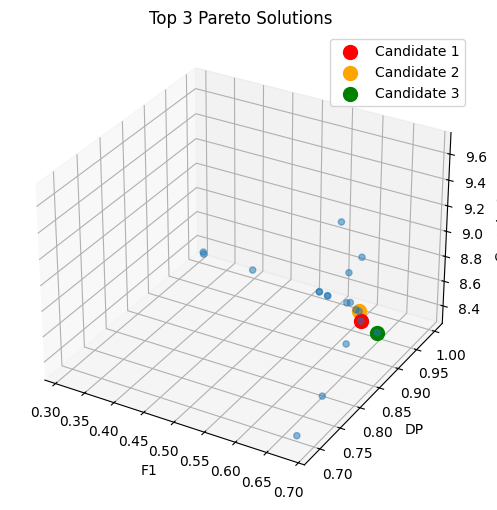

In [45]:
# 3D Highlighted Pareto

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(f1_p, dp_p, comp_p, alpha=0.5)

for i, idx in enumerate(top3_idx):
    ax.scatter(
        f1_p[idx],
        dp_p[idx],
        comp_p[idx],
        color=colors[i],
        s=100,
        label=f"Candidate {i+1}"
    )

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

ax.set_title("Top 3 Pareto Solutions")

ax.legend()
plt.show()

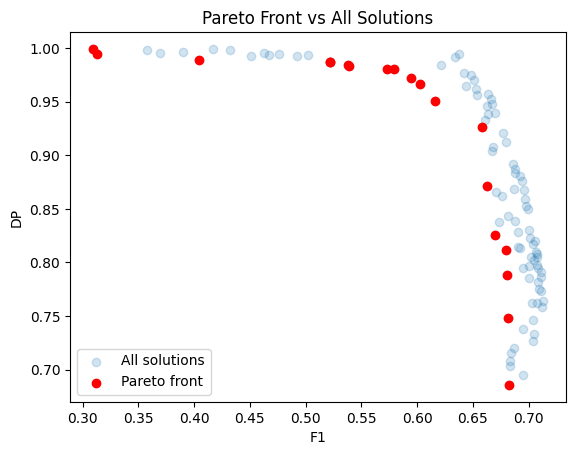

In [46]:
# Overlay (All vs Pareto) 

f1_all = f1
dp_all = dp

plt.scatter(f1_all, dp_all, alpha=0.2, label="All solutions")
plt.scatter(f1_p, dp_p, color='red', label="Pareto front")

plt.xlabel("F1")
plt.ylabel("DP")
plt.legend()
plt.title("Pareto Front vs All Solutions")
plt.show()

### COMPUTING HYPER VOLUME (HV), SPACING and SAMPLE PARETO POINTS

In [58]:
F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0))

ref_point = np.array([1.1, 1.1, 1.1]) 

hv = HV(ref_point=ref_point)
hv_value = hv.do(F_norm)

print("Hypervolume:", hv_value)

Hypervolume: 0.3922259520383619


In [53]:
def spacing_metric(F):
    D = cdist(F, F)
    np.fill_diagonal(D, np.inf)
    
    d = np.min(D, axis=1)
    return np.std(d)

spacing = spacing_metric(F_pareto)
print("Spacing:", spacing)

Spacing: 0.10220575369705699


In [54]:
pareto_table = pd.DataFrame({
    "F1": f1_p,
    "DP": dp_p,
    "Complexity": comp_p
})

pareto_table_sorted = pareto_table.sort_values("F1", ascending=False)

print(pareto_table_sorted.head(6))

          F1        DP  Complexity
0   0.682329  0.685607    8.364573
12  0.681199  0.748441    8.469237
17  0.680477  0.788635    9.667699
18  0.679519  0.811694    9.225208
9   0.669442  0.825271    8.622283
15  0.663033  0.871398    9.152210


In [55]:
best_f1_idx = np.argmax(f1_p)
best_dp_idx = np.argmax(dp_p)

print("Best F1:", f1_p[best_f1_idx], dp_p[best_f1_idx])
print("Best DP:", f1_p[best_dp_idx], dp_p[best_dp_idx])

Best F1: 0.6823290404389674 0.6856067930507085
Best DP: 0.30884184308841844 0.9989653012892072
